In [1]:
import fdfi
print('FDFI version:', fdfi.__version__)

FDFI version: 0.0.9


# Confidence Intervals and Statistical Inference

This tutorial covers statistical inference with FDFI, including confidence intervals, hypothesis testing, and feature selection.

## What You'll Learn

1. Computing confidence intervals with `conf_int()`
2. One-sided vs two-sided tests
3. Variance floor for stable inference
4. Practical significance margins
5. Statistically-driven feature selection

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from fdfi.explainers import OTExplainer
from fdfi.plots import confidence_interval_plot

np.random.seed(42)

## Setup

Create a model where we know the true feature importance:

In [3]:
n_features = 10
n_train = 500
n_test = 100

# True importance: features 0, 1, 2 are important; rest are noise
true_coefs = np.array([2.0, 1.5, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

def model(X):
    return X @ true_coefs

X_train = np.random.randn(n_train, n_features)
X_test = np.random.randn(n_test, n_features)

# Create explainer
explainer = OTExplainer(model, data=X_train, nsamples=100)
results = explainer(X_test)

print("True coefficients:", true_coefs)
print("Estimated importance:", results["phi_X"].round(3))

True coefficients: [2.  1.5 0.5 0.  0.  0.  0.  0.  0.  0. ]
Estimated importance: [3.641e+00 2.674e+00 2.270e-01 7.000e-03 1.200e-02 7.000e-03 4.000e-03
 1.000e-03 9.000e-03 1.500e-02]


## Basic Confidence Intervals

The `conf_int()` method computes pointwise confidence intervals:

In [4]:
# Two-sided 95% confidence intervals
ci = explainer.conf_int(alpha=0.05, alternative="two-sided")

print("Two-sided 95% Confidence Intervals:")
print("-" * 70)
print(f"{'Feature':>8} {'Estimate':>10} {'SE':>10} {'CI Lower':>10} {'CI Upper':>10} {'P-value':>10}")
print("-" * 70)
for i in range(n_features):
    sig = "*" if ci["pvalue"][i] < 0.05 else ""
    print(f"{i:>8} {ci['score'][i]:>10.4f} {ci['se'][i]:>10.4f} "
          f"{ci['ci_lower'][i]:>10.4f} {ci['ci_upper'][i]:>10.4f} {ci['pvalue'][i]:>10.4f} {sig}")

Two-sided 95% Confidence Intervals:
----------------------------------------------------------------------
 Feature   Estimate         SE   CI Lower   CI Upper    P-value
----------------------------------------------------------------------
       0     3.6412     0.5222     2.6177     4.6646     0.0000 *
       1     2.6736     0.3974     1.8947     3.4524     0.0000 *
       2     0.2268     0.0410     0.1465     0.3071     0.0000 *
       3     0.0073     0.0230    -0.0378     0.0524     0.7334 
       4     0.0116     0.0230    -0.0336     0.0567     0.8771 
       5     0.0067     0.0230    -0.0384     0.0519     0.7157 
       6     0.0037     0.0230    -0.0414     0.0488     0.6186 
       7     0.0008     0.0230    -0.0443     0.0459     0.5346 
       8     0.0090     0.0230    -0.0361     0.0542     0.7910 
       9     0.0151     0.0230    -0.0300     0.0603     1.0000 


## Visualize Confidence Intervals

(<Figure size 800x490 with 1 Axes>,
 <Axes: title={'center': 'FDFI Confidence Intervals'}, xlabel='FDFI score with confidence interval'>)

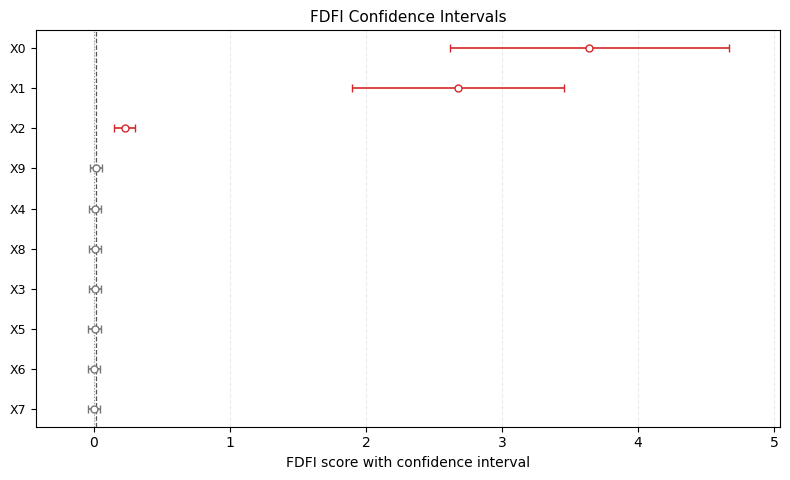

In [5]:
feature_names = [f"X{i}" for i in range(n_features)]

confidence_interval_plot(
    ci,
    feature_names=feature_names,
    show=False,
)

## One-Sided Tests

For feature importance, we often care if a feature has **positive** importance. Use `alternative="greater"`:

In [6]:
# One-sided test: H0: phi <= 0 vs H1: phi > 0
ci_greater = explainer.conf_int(alpha=0.05, alternative="greater")

print("One-sided test (phi > 0):")
print("-" * 60)
print(f"{'Feature':>8} {'Estimate':>10} {'CI Lower':>10} {'P-value':>10} {'Significant':>12}")
print("-" * 60)
for i in range(n_features):
    sig = "Yes" if ci_greater["reject_null"][i] else "No"
    print(f"{i:>8} {ci_greater['score'][i]:>10.4f} "
          f"{ci_greater['ci_lower'][i]:>10.4f} {ci_greater['pvalue'][i]:>10.4f} {sig:>12}")

One-sided test (phi > 0):
------------------------------------------------------------
 Feature   Estimate   CI Lower    P-value  Significant
------------------------------------------------------------
       0     3.6412     2.7822     0.0000          Yes
       1     2.6736     2.0199     0.0000          Yes
       2     0.2268     0.1594     0.0000          Yes
       3     0.0073    -0.0306     0.6333           No
       4     0.0116    -0.0263     0.5614           No
       5     0.0067    -0.0311     0.6421           No
       6     0.0037    -0.0342     0.6907           No
       7     0.0008    -0.0370     0.7327           No
       8     0.0090    -0.0289     0.6045           No
       9     0.0151    -0.0228     0.5000           No


## Variance Floor

When some features have very small variance in their importance estimates, confidence intervals can become too narrow. The **variance floor** adds a minimum standard error.

Two methods are available:
- `fixed`: Use a constant floor value
- `mixture`: Fit a two-component mixture to estimate the floor

In [7]:
# Without variance floor
ci_no_floor = explainer.conf_int(alpha=0.05, var_floor_c=0)

# With fixed variance floor
ci_fixed = explainer.conf_int(alpha=0.05, var_floor_method="fixed", var_floor_c=0.1)

# With mixture-based floor
ci_mixture = explainer.conf_int(alpha=0.05, var_floor_method="mixture", var_floor_quantile=0.95)

print("Standard errors comparison:")
print("-" * 55)
print(f"{'Feature':>8} {'No Floor':>12} {'Fixed':>12} {'Mixture':>12}")
print("-" * 55)
for i in range(n_features):
    print(f"{i:>8} {ci_no_floor['se'][i]:>12.4f} {ci_fixed['se'][i]:>12.4f} {ci_mixture['se'][i]:>12.4f}")

Standard errors comparison:
-------------------------------------------------------
 Feature     No Floor        Fixed      Mixture
-------------------------------------------------------
       0       0.5222       0.5218       0.5222
       1       0.3974       0.3968       0.3974
       2       0.0410       0.0353       0.0410
       3       0.0230       0.0100       0.0230
       4       0.0230       0.0101       0.0230
       5       0.0230       0.0100       0.0230
       6       0.0230       0.0100       0.0230
       7       0.0230       0.0100       0.0230
       8       0.0230       0.0100       0.0230
       9       0.0230       0.0101       0.0230


## Practical Significance Margin

Instead of testing $H_0: \phi = 0$, you can test against a **practical threshold** $\delta$:

$$H_0: \phi \leq \delta \quad \text{vs} \quad H_1: \phi > \delta$$

This identifies features that are not just statistically different from zero, but also practically meaningful.

In [8]:
# Test with practical margin of 0.5
margin = 0.5
ci_margin = explainer.conf_int(
    alpha=0.05, 
    alternative="greater",
    margin=margin
)

print(f"Testing H0: phi <= {margin}")
print("-" * 50)
print(f"{'Feature':>8} {'Estimate':>10} {'P-value':>10} {'Significant':>12}")
print("-" * 50)
for i in range(n_features):
    sig = "Yes" if ci_margin["reject_null"][i] else "No"
    print(f"{i:>8} {ci_margin['score'][i]:>10.4f} {ci_margin['pvalue'][i]:>10.4f} {sig:>12}")

Testing H0: phi <= 0.5
--------------------------------------------------
 Feature   Estimate    P-value  Significant
--------------------------------------------------
       0     3.6412     0.0000          Yes
       1     2.6736     0.0000          Yes
       2     0.2268     0.0000          Yes
       3     0.0073     0.6333           No
       4     0.0116     0.5614           No
       5     0.0067     0.6421           No
       6     0.0037     0.6907           No
       7     0.0008     0.7327           No
       8     0.0090     0.6045           No
       9     0.0151     0.5000           No


## Automatic Margin via Mixture Model

Use `margin_method="mixture"` to automatically estimate a practical margin:

In [9]:
ci_auto_margin = explainer.conf_int(
    alpha=0.05,
    alternative="greater",
    margin_method="mixture",
    margin_quantile=0.95,
)

print(f"Automatically selected margin: {ci_auto_margin['margin']:.4f}")
print(f"Significant features: {np.where(ci_auto_margin['reject_null'])[0]}")

Automatically selected margin: 0.1545
Significant features: [0 1 2]


## Feature Selection with Statistical Guarantees

Use the confidence intervals to select features with controlled false discovery:

In [10]:
def statistical_feature_selection(explainer, X_test, alpha=0.05, margin=0.0):
    """Select features with statistical significance."""
    # Compute importance
    results = explainer(X_test)
    
    # Get confidence intervals
    ci = explainer.conf_int(
        alpha=alpha,
        alternative="greater",
        margin=margin,
        var_floor_method="mixture",
    )
    
    # Select significant features
    selected = np.where(ci["reject_null"])[0]
    
    # Sort by importance
    sorted_idx = np.argsort(ci["score"][selected])[::-1]
    
    return selected[sorted_idx], ci

# Run feature selection
selected_features, ci_result = statistical_feature_selection(
    explainer, X_test, alpha=0.05, margin=0.0
)

print("Selected Features (sorted by importance):")
print("-" * 40)
for i, feat in enumerate(selected_features):
    print(f"  {i+1}. Feature {feat} (importance = {ci_result['score'][feat]:.4f})")

print(f"\nTrue important features: 0, 1, 2")
print(f"Correctly identified: {set(selected_features) & {0, 1, 2}}")

Selected Features (sorted by importance):
----------------------------------------
  1. Feature 0 (importance = 3.6412)
  2. Feature 1 (importance = 2.6736)
  3. Feature 2 (importance = 0.2268)

True important features: 0, 1, 2
Correctly identified: {0, 1, 2}


## The `summary()` Method

For a quick formatted view, use the built-in `summary()` method:

In [11]:
# Print formatted summary
explainer.summary(
    alpha=0.05,
    alternative="greater",
    var_floor_method="mixture",
)

Feature Importance Results
Method: OTExplainer
Number of units: 10
Significance level: 0.05
Alternative: greater
Margin method: gap
Practical margin: 0.0151
------------------------------------------------------------------------------
        Feature   Estimate    Std Err   CI Lower   CI Upper    P-value   Sig
------------------------------------------------------------------------------
              0     3.6412     0.5222     2.7822        inf     0.0000   ***
              1     2.6736     0.3974     2.0199        inf     0.0000   ***
              2     0.2268     0.0410     0.1594        inf     0.0000   ***
              3     0.0073     0.0230    -0.0306        inf     0.6333      
              4     0.0116     0.0230    -0.0263        inf     0.5614      
              5     0.0067     0.0230    -0.0311        inf     0.6421      
              6     0.0037     0.0230    -0.0342        inf     0.6907      
              7     0.0008     0.0230    -0.0370        inf     0.732

"==============================================================================\nFeature Importance Results\n==============================================================================\nMethod: OTExplainer\nNumber of units: 10\nSignificance level: 0.05\nAlternative: greater\nMargin method: gap\nPractical margin: 0.0151\n------------------------------------------------------------------------------\n        Feature   Estimate    Std Err   CI Lower   CI Upper    P-value   Sig\n------------------------------------------------------------------------------\n              0     3.6412     0.5222     2.7822        inf     0.0000   ***\n              1     2.6736     0.3974     2.0199        inf     0.0000   ***\n              2     0.2268     0.0410     0.1594        inf     0.0000   ***\n              3     0.0073     0.0230    -0.0306        inf     0.6333      \n              4     0.0116     0.0230    -0.0263        inf     0.5614      \n              5     0.0067     0.0230    -0.031

## Multiple Testing Correction

When explaining models with many features, it is important to control the false discovery rate (FDR). You can specify a `multitest_method` in both `conf_int()` and `summary()`:

In [12]:
# Summary with FDR control (Benjamini-Hochberg)
explainer.summary(
    alpha=0.05,
    alternative="greater",
    multitest_method="fdr_bh"
)

Feature Importance Results
Method: OTExplainer
Number of units: 10
Significance level: 0.05
Alternative: greater
Multiple testing: fdr_bh
Margin method: gap
Practical margin: 0.0151
------------------------------------------------------------------------------
        Feature   Estimate    Std Err   CI Lower   CI Upper  Adj P-val   Sig
------------------------------------------------------------------------------
              0     3.6412     0.5222     2.7822        inf     0.0000   ***
              1     2.6736     0.3974     2.0199        inf     0.0000   ***
              2     0.2268     0.0410     0.1594        inf     0.0000   ***
              3     0.0073     0.0230    -0.0306        inf     0.7327      
              4     0.0116     0.0230    -0.0263        inf     0.7327      
              5     0.0067     0.0230    -0.0311        inf     0.7327      
              6     0.0037     0.0230    -0.0342        inf     0.7327      
              7     0.0008     0.0230    -0.

"==============================================================================\nFeature Importance Results\n==============================================================================\nMethod: OTExplainer\nNumber of units: 10\nSignificance level: 0.05\nAlternative: greater\nMultiple testing: fdr_bh\nMargin method: gap\nPractical margin: 0.0151\n------------------------------------------------------------------------------\n        Feature   Estimate    Std Err   CI Lower   CI Upper  Adj P-val   Sig\n------------------------------------------------------------------------------\n              0     3.6412     0.5222     2.7822        inf     0.0000   ***\n              1     2.6736     0.3974     2.0199        inf     0.0000   ***\n              2     0.2268     0.0410     0.1594        inf     0.0000   ***\n              3     0.0073     0.0230    -0.0306        inf     0.7327      \n              4     0.0116     0.0230    -0.0263        inf     0.7327      \n              5     0

## Visualising One-Sided and Two-Sided Confidence Intervals

`confidence_interval_plot` automatically adapts to the `alternative` stored
inside the `conf_int()` result dictionary:

* **Two-sided** (`alternative="two-sided"`): both caps are flat bars.
* **One-sided greater** (`alternative="greater"`): the open upper bound is shown
  as a short stub with a **◄** limit indicator at its tip (matplotlib's native
  `xuplims` convention), a corner annotation, and a label noting *H₁: φ > margin*.
* **One-sided less** (`alternative="less"`): the open lower bound is shown with
  a **►** limit indicator at its tip (`xlolims` convention).

The figure below shows both variants side-by-side on synthetic data.

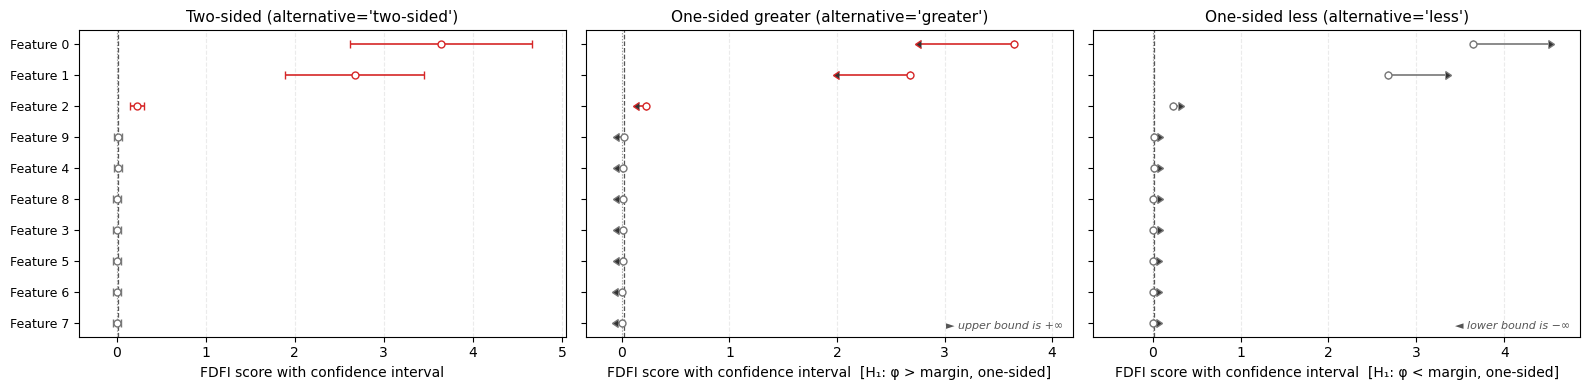

In [13]:
import matplotlib.pyplot as plt
from fdfi.plots import confidence_interval_plot

# --- two-sided CI ---
ci_two = explainer.conf_int(alpha=0.05, alternative="two-sided")

# --- one-sided greater CI ---
ci_greater = explainer.conf_int(alpha=0.05, alternative="greater")

# --- one-sided less CI (for illustration) ---
ci_less = explainer.conf_int(alpha=0.05, alternative="less")

feature_labels = [f"Feature {i}" for i in range(n_features)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

confidence_interval_plot(
    ci_two,
    feature_names=feature_labels,
    ax=axes[0],
    show=False,
    title="Two-sided (alternative='two-sided')",
)
confidence_interval_plot(
    ci_greater,
    feature_names=feature_labels,
    ax=axes[1],
    show=False,
    title="One-sided greater (alternative='greater')",
)
confidence_interval_plot(
    ci_less,
    feature_names=feature_labels,
    ax=axes[2],
    show=False,
    title="One-sided less (alternative='less')",
)

fig.tight_layout()
plt.show()

## Summary


Key takeaways:

1. `conf_int()` provides confidence intervals and p-values for feature importance
2. Use `alternative="greater"` for one-sided tests of positive importance
3. Variance floor (`var_floor_method`) stabilizes inference for small effects
4. Practical margin (`margin`) tests against meaningful thresholds
5. Use `summary()` for quick formatted output